In [1]:
from Complex_bug_impurity_solver import *
from utils import *
from Tree_topology import *
import scipy.sparse.linalg
from matplotlib.pyplot import subplots, show
from numpy import linalg
from pytreenet.ttns.ttns_ttno.application import (
    apply_ttno_to_ttns,
    ApplicationMethod,
)
import matplotlib.pyplot as plt
from TreeTopologies import random_impurity_binary_tree_ttn


In [53]:
#Benchmarking of the SIAM without bath
angle = -np.pi/50
eshift = 0.0
n_bath = 1
chi_max = 16
U = 1.5
dt = 0.1
tend = 10
D=1.0

# hopping terms
#hop =  Discretisation_function(D, n_bath)[0] #np.ones(n_bath)
hop= np.ones(n_bath)
# bath on-site energy
#eb =   Discretisation_function(D, n_bath)[1] 
eb =np.ones(n_bath)

# impurity on-site energy
ei = -U/2

binary_ttn = random_impurity_binary_tree_ttn(n_bath=n_bath, chi_max=chi_max)
state = TreeTensorNetworkState.from_ttn(binary_ttn)
state.normalise()

np.float64(24.354292427309304)

In [54]:
siam_ttno =SIAM_Hamiltonian(state,angle,eshift,n_bath,hop,eb,ei,U)
siam_ttno_physical= SIAM_Hamiltonian(state,0,eshift,n_bath,hop,eb,ei,U)

In [55]:
#Running time evolution iterativley to construct Krylov subspace
operators = {
    "energy": siam_ttno,
}

psi_0,order_full= state.completely_contract_tree(to_copy=True,)
psi_0_clean=np.asarray(psi_0, dtype=complex).reshape(-1)
state_0=psi_0_clean    
time_step_size=0.001
final_time=1.0
M=10
max_bond_dim=10

In [56]:
import timeit
Krylov_vectors=[state_0]
bond_dimension=[]
timeit.Timer() 
for i in range(M):
    print(f"Iteration {i+1} out of {M}")
    tree_bug, results_tilted, times_tilted = BUG_time_evolution(Tree_state=state,TTNO_Hamil=siam_ttno,time_step_size=time_step_size,final_time=final_time,
    operators=operators,
    max_bond_dim=max_bond_dim,
    rel_tol=1e-12,
    abs_tol=1e-12)
    #print(results_tilted)
    bond_dimension.append(np.max(results_tilted["max_bond_dim"]))
    psi_n,order= tree_bug.state.completely_contract_tree(
        to_copy=True,order= order_full)
    psi_clean=np.asarray(psi_n, dtype=complex).reshape(-1)
    Krylov_vectors.append(psi_clean)
    state= tree_bug.state

Iteration 1 out of 10


100%|██████████| 1001/1001 [00:10<00:00, 92.04it/s]


Iteration 2 out of 10


100%|██████████| 1001/1001 [00:11<00:00, 90.64it/s]


Iteration 3 out of 10


...

100%|██████████| 1001/1001 [00:09<00:00, 109.57it/s]


Iteration 9 out of 10


100%|██████████| 1001/1001 [00:08<00:00, 111.59it/s]


Iteration 10 out of 10


100%|██████████| 1001/1001 [00:09<00:00, 110.26it/s]


In [57]:
siam_dense,order= siam_ttno_physical.as_matrix(order= order_full)
eigenvalues, eigenvectors = linalg.eig(siam_dense)
eigenvalues.sort()
X,eigen=Grams_schmidt(Krylov_vectors,tolerance= 0.0)

E, Q, ritz_vectors, residuals, relative_residuals = (krylov_projection(siam_dense,X,Krylov_vectors,tol=1.0))

idx = np.argsort(E)

E = E[idx]
Q = Q[:, idx]
residuals = residuals[idx]
ritz_data = np.column_stack([E,residuals,relative_residuals])

#np.savetxt(f"ritz_results_bond_dimension_{max_bond_dim}.csv",ritz_data,delimiter=",",header="energy,residual,relative_residual")
E_MC,_,_= exact_imaginary_time_evolution(Krylov_vectors[0],siam_dense,10.0)
print("ED:",eigenvalues)
print("Imaginary Time evolution:",E_MC)
print("Krylov subspace:",E)

V = np.column_stack([np.asarray(v, dtype=np.complex128)for v in Krylov_vectors])

Q_full = V @ X @ Q

# Normalize reconstructed Ritz vectors
for i in range(Q_full.shape[1]):Q_full[:, i] /= np.linalg.norm(Q_full[:, i])

psi_list_krylov = [Q_full[:, i]for i in range(Q_full.shape[1])]

Ritz values and residuals:
 0: E = -1.5771829096, residual = 4.223e-14, relative = 2.678e-14
 1: E = -1.2037682266, residual = 4.516e-14, relative = 3.751e-14
 2: E = -0.0000000000, residual = 7.286e-13, relative = 7.286e-13
 3: E =  0.1172177815, residual = 2.243e-12, relative = 2.243e-12
 4: E =  0.2500000000, residual = 8.605e-13, relative = 8.605e-13
 5: E =  0.8526179494, residual = 3.020e-13, relative = 3.020e-13
 6: E =  1.4537682266, residual = 2.081e-13, relative = 1.431e-13
 7: E =  2.0000000000, residual = 2.520e-12, relative = 1.260e-12
 8: E =  2.1327822185, residual = 1.517e-12, relative = 7.112e-13
 9: E =  2.9745649602, residual = 9.468e-13, relative = 3.183e-13
ED: [-1.57718291+0.j -1.20376823+0.j -1.20376823+0.j  0.        +0.j
  0.11721778+0.j  0.11721778+0.j  0.25      +0.j  0.25      +0.j
  0.25      +0.j  0.85261795+0.j  1.45376823+0.j  1.45376823+0.j
  2.        +0.j  2.13278222+0.j  2.13278222+0.j  2.97456496+0.j]
Imaginary Time evolution: -1.5765039785447024
Kr

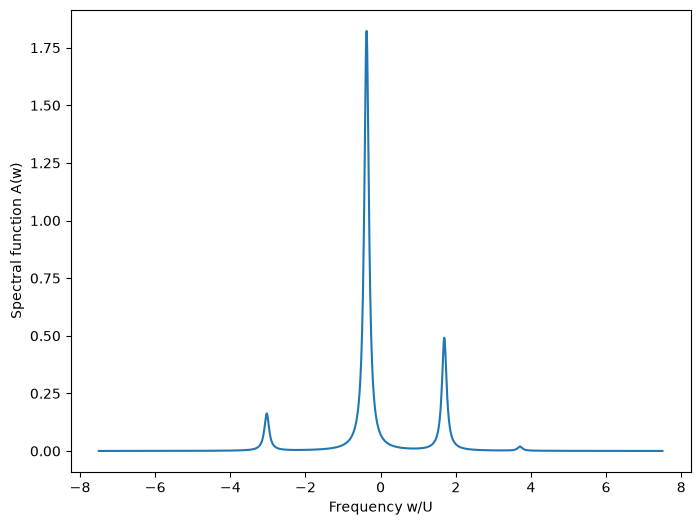

In [58]:
c, a, n = construct_spinful_fermionic_operators(2)

d = a[0][0]   # impurity up annihilation operator

omega = np.linspace(-5 * U,5 * U,2000)

eta = 0.05 * U

G_krylov = np.array([Greens_function_lehman(d,E,psi_list_krylov,eta,w) for w in omega])


A_krylov = spectral_function(G_krylov)
fig, ax = plt.subplots(1,1,figsize=(8, 6))
ax.set_xlabel('Frequency w/U', fontsize=10)
ax.set_ylabel("Spectral function A(w)",fontsize=10)
ax.plot(omega,A_krylov)
#plt.xlim(-1.5,1.5)

In [59]:
spectral_weight = np.trapezoid(A_krylov,omega)

print("Integrated spectral weight:", spectral_weight)

Integrated spectral weight: 0.5835231067040862


[-1.57718291+0.j  0.85261795+0.j  2.97456496+0.j  1.45376823+0.j
 -1.20376823+0.j  1.45376823+0.j -1.20376823+0.j  0.25      +0.j
  2.13278222+0.j  0.11721778+0.j  0.11721778+0.j  2.13278222+0.j
  0.        +0.j  0.25      +0.j  0.25      +0.j  2.        +0.j]


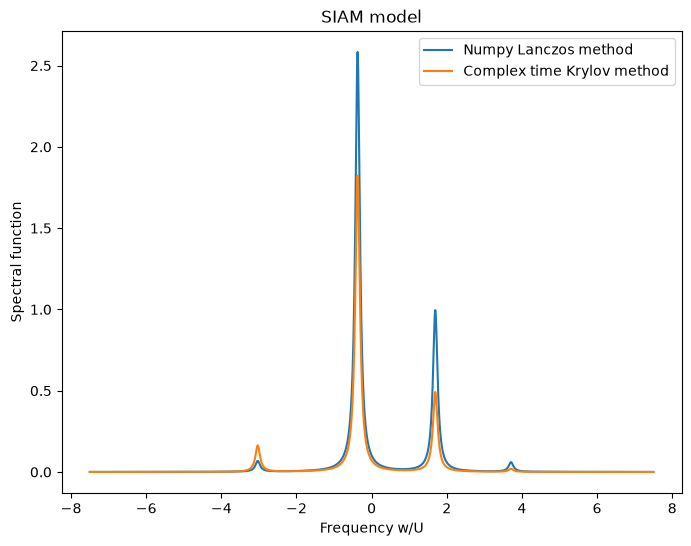

In [60]:
E_exact, psi_exact = (linalg.eig(siam_dense))
print(E_exact)
idx = np.argsort(E_exact)

E_exact = E_exact[idx]
psi_exact = psi_exact[:, idx]

psi_list_exact = [psi_exact[:, i] for i in range(psi_exact.shape[1])]

G_exact = np.array([Greens_function_lehman(d,E_exact,psi_list_exact,eta,w,) for w in omega ])
A_exact= spectral_function(np.asarray(G_exact))

fig, ax = plt.subplots(1,1,figsize=(8, 6))
ax.set_xlabel('Frequency w/U', fontsize=10)
ax.set_ylabel("Spectral function",fontsize=10)
ax.plot(omega,A_exact,label="Numpy Lanczos method")
ax.plot(omega,A_krylov,label="Complex time Krylov method")
plt.title("SIAM model")
plt.legend()
#plt.savefig("SIAM_model_small.pdf")
#plt.xlim(-1.5,1.5)
#plt.ylim(0,1)

In [61]:
spectral_weight = np.trapezoid(A_exact,omega)

print("Integrated spectral weight:", spectral_weight)

Integrated spectral weight: 0.8665310760940079


In [15]:
S_1=[]
S_2=[]
S_3=[]
S_4=[]
S_lists=[S_1,S_2,S_3,S_4]
contour_list=[-np.pi/3,-np.pi/4,-np.pi/20,-np.pi/100]
count=0
    

for angle in contour_list:   
#Benchmarking of the SIAM without bath
    S_eigen_values=[1.0] 
    eshift = 0.0
    n_bath = 1
    chi_max = 16
    U = 1.5
    dt = 0.1
    tend = 10
    D=1.0

    # hopping terms
    #hop =  Discretisation_function(D, n_bath)[0] #np.ones(n_bath)
    hop= np.ones(n_bath)
    # bath on-site energy
    #eb =   Discretisation_function(D, n_bath)[1] 
    eb =np.ones(n_bath)

    # impurity on-site energy
    ei = -U/2

    binary_ttn = random_impurity_binary_tree_ttn(n_bath=n_bath, chi_max=chi_max)
    state = TreeTensorNetworkState.from_ttn(binary_ttn)
    state.normalise()
    siam_ttno =SIAM_Hamiltonian(state,angle,eshift,n_bath,hop,eb,ei,U)
    siam_ttno_physical= SIAM_Hamiltonian(state,0,eshift,n_bath,hop,eb,ei,U)
    #Running time evolution iterativley to construct Krylov subspace
    operators = {
        "energy": siam_ttno,
    }

    psi_0,order_full= state.completely_contract_tree(to_copy=True,)
    psi_0_clean=np.asarray(psi_0, dtype=complex).reshape(-1)
    state_0=psi_0_clean    
    time_step_size=0.01
    final_time=1.0
    M=15
    max_bond_dim=10
    Krylov_vectors=[state_0]
    bond_dimension=[]

    for i in range(M):
        tree_bug, results_tilted, times_tilted = BUG_time_evolution(Tree_state=state,TTNO_Hamil=siam_ttno,time_step_size=time_step_size,final_time=final_time,
        operators=operators,
        max_bond_dim=max_bond_dim,
        rel_tol=1e-12,
        abs_tol=1e-12)
        #print(results_tilted)
        bond_dimension.append(np.max(results_tilted["max_bond_dim"]))
        psi_n,order= tree_bug.state.completely_contract_tree(
            to_copy=True,order= order_full)
        psi_clean=np.asarray(psi_n, dtype=complex).reshape(-1)
        Krylov_vectors.append(psi_clean)
        state= tree_bug.state
        X,eigen=Grams_schmidt(Krylov_vectors,tolerance= 0.0)
        S_eigen_values.append(np.min(eigen))
    #print(count)
    S_lists[count]=S_eigen_values
    count+=1
    
    
    
    

100%|██████████| 101/101 [00:00<00:00, 118.66it/s]


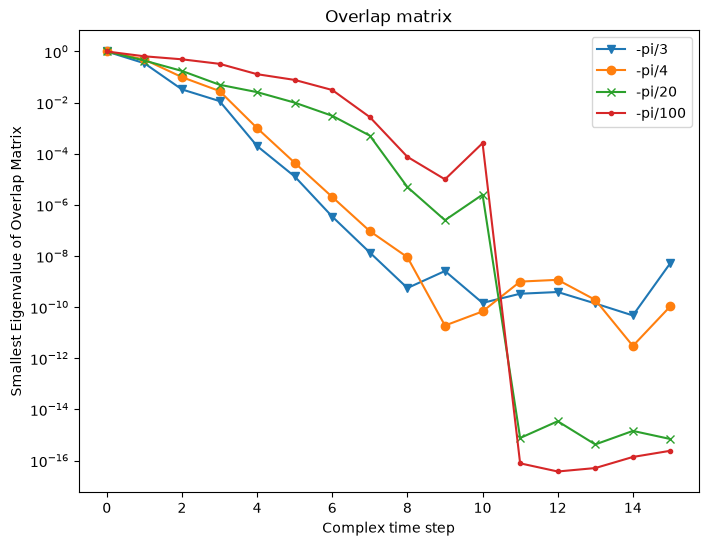

In [17]:
fig, ax = plt.subplots(1,1,figsize=(8, 6))
ax.set_xlabel('Complex time step', fontsize=10)
ax.set_ylabel("Smallest Eigenvalue of Overlap Matrix",fontsize=10)
ax.set_yscale('log')
ax.plot(range(0,M+1),S_lists[0],marker="v",label="-pi/3")
ax.plot(range(0,M+1),S_lists[1],marker="o",label="-pi/4")
ax.plot(range(0,M+1),S_lists[2],marker="x",label="-pi/20")
ax.plot(range(0,M+1),S_lists[3],marker=".",label="-pi/100")
plt.title("Overlap matrix with different contour factors")
plt.legend()
#plt.xlim(-0.5,10.1)
#plt.savefig("SIAM_overlap.pdf")
#log axis 


In [74]:
#Only operate on the TTNS no contraction

angle = -np.pi/100
eshift = 0.0
n_bath = 4
chi_max = 16
U = 1.5
dt = 0.1
tend = 10
D=1.0

# hopping terms
hop =  Discretisation_function(D, n_bath)[0] #np.ones(n_bath)
#hop= np.ones(n_bath)
#bath on-site energy
eb =   Discretisation_function(D, n_bath)[1] 
#eb =np.ones(n_bath)

# impurity on-site energy
ei = -U/2

binary_ttn = random_impurity_binary_tree_ttn(n_bath=n_bath, chi_max=chi_max)
state = TreeTensorNetworkState.from_ttn(binary_ttn)
state.normalise()



np.float64(1089457.0932931849)

In [75]:
siam_ttno =SIAM_Hamiltonian(state,angle,eshift,n_bath,hop,eb,ei,U)
siam_ttno_physical= SIAM_Hamiltonian(state,0,eshift,n_bath,hop,eb,ei,U)
#Running time evolution iterativley to construct Krylov subspace
operators = {
    "energy": siam_ttno,
}

   
time_step_size=0.001
final_time=1.0
M=15
max_bond_dim=10

In [76]:
Krylov_states= Complex_time_evolution(binary_ttn,siam_ttno,time_step_size,final_time,max_bond_dim,operators,M)

Iteration 1 out of 15


100%|██████████| 1001/1001 [01:30<00:00, 11.09it/s]


Iteration 2 out of 15


100%|██████████| 1001/1001 [01:31<00:00, 10.99it/s]


Iteration 3 out of 15


...

100%|██████████| 1001/1001 [01:30<00:00, 11.01it/s]


Iteration 14 out of 15


100%|██████████| 1001/1001 [01:28<00:00, 11.36it/s]


Iteration 15 out of 15


100%|██████████| 1001/1001 [01:32<00:00, 10.80it/s]


In [77]:
X, eig= Gram_schmidt_TTN(Krylov_states,tolerance= 0.0,Keep_all=False)
print(np.shape(X))


(16, 16)


In [78]:
energies, Q,c,r,rr=krylov_projection_TTN(siam_ttno_physical,X,Krylov_states,Keep_all=False)
idx = np.argsort(energies)
r=r[idx]
siam_dense,order= siam_ttno_physical.as_matrix(order= order_full)
eigenvalues, eigenvectors = linalg.eig(siam_dense)
eigenvalues.sort()
print(f"ED: {np.real(eigenvalues)}")

Ritz values and residuals:


ValueError: The order is inconsistent with the structure of the tree!

In [ ]:
omega = np.linspace(-5 * U,5 * U,2000)

eta = 0.05 * U

G_krylov = np.array([Greens_function_lehman_TTN(energies,c,Krylov_states,eta,w) for w in omega])


A_krylov = spectral_function(G_krylov)
fig, ax = plt.subplots(1,1,figsize=(8, 6))
ax.set_xlabel('Frequency w/U', fontsize=10)
ax.set_ylabel("Spectral function A(w)",fontsize=10)
ax.plot(omega,A_krylov)
#plt.xlim(-1.5,1.5)


[-1.57718291+0.j  0.85261795+0.j  2.97456496+0.j  1.45376823+0.j
 -1.20376823+0.j  1.45376823+0.j -1.20376823+0.j  0.25      +0.j
  2.13278222+0.j  0.11721778+0.j  0.11721778+0.j  2.13278222+0.j
  0.        +0.j  0.25      +0.j  0.25      +0.j  2.        +0.j]


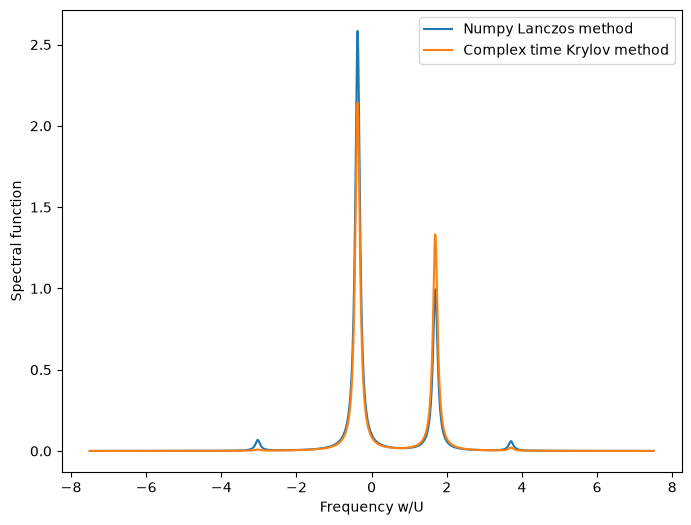

In [73]:
E_exact, psi_exact = (linalg.eig(siam_dense))
print(E_exact)
idx = np.argsort(E_exact)

E_exact = E_exact[idx]
psi_exact = psi_exact[:, idx]

psi_list_exact = [psi_exact[:, i] for i in range(psi_exact.shape[1])]

G_exact = np.array([Greens_function_lehman(d,E_exact,psi_list_exact,eta,w,) for w in omega ])
A_exact= spectral_function(np.asarray(G_exact))

fig, ax = plt.subplots(1,1,figsize=(8, 6))
ax.set_xlabel('Frequency w/U', fontsize=10)
ax.set_ylabel("Spectral function",fontsize=10)
ax.plot(omega,A_exact,label="Numpy Lanczos method")
ax.plot(omega,A_krylov,label="Complex time Krylov method")
#plt.title("SIAM model")
plt.legend()
#plt.savefig("SIAM_model_small.pdf")
#plt.xlim(-1.5,1.5)
#plt.ylim(0,1)